# KNN with Scikit Learn

- KNN is easy to implement and works well for small datasets
- Choosing the right value of K is crucial, and cross-validation helps - select the optimal value
- Distance metrics and weighting can improve performance for certain problems

1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [2]:
#load dataset
df = pd.read_csv('churn.csv')
df


,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3328,AZ,192,415,414-4276,no,yes,36,156.2,77,26.55,...,126,18.32,279.1,83,12.56,9.9,6,2.67,2,False
3329,WV,68,415,370-3271,no,no,0,231.1,57,39.29,...,55,13.04,191.3,123,8.61,9.6,4,2.59,3,False
3330,RI,28,510,328-8230,no,no,0,180.8,109,30.74,...,58,24.55,191.9,91,8.64,14.1,6,3.81,2,False
3331,CT,184,510,364-6381,yes,no,0,213.8,105,36.35,...,84,13.57,139.2,137,6.26,5.0,10,1.35,2,False


In [3]:
#one hot coding
df_new = pd.get_dummies(df, drop_first=True)
df_new

,account length,area code,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,...,phone number_422-5874,phone number_422-6685,phone number_422-6690,phone number_422-7728,phone number_422-8268,phone number_422-8333,phone number_422-8344,phone number_422-9964,international plan_yes,voice mail plan_yes
0,128,415,25,265.1,110,45.07,197.4,99,16.78,244.7,...,0,0,0,0,0,0,0,0,0,1
1,107,415,26,161.6,123,27.47,195.5,103,16.62,254.4,...,0,0,0,0,0,0,0,0,0,1
2,137,415,0,243.4,114,41.38,121.2,110,10.30,162.6,...,0,0,0,0,0,0,0,0,0,0
3,84,408,0,299.4,71,50.90,61.9,88,5.26,196.9,...,0,0,0,0,0,0,0,0,1,0
4,75,415,0,166.7,113,28.34,148.3,122,12.61,186.9,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3328,192,415,36,156.2,77,26.55,215.5,126,18.32,279.1,...,0,0,0,0,0,0,0,0,0,1
3329,68,415,0,231.1,57,39.29,153.4,55,13.04,191.3,...,0,0,0,0,0,0,0,0,0,0
3330,28,510,0,180.8,109,30.74,288.8,58,24.55,191.9,...,0,0,0,0,0,0,0,0,0,0
3331,184,510,0,213.8,105,36.35,159.6,84,13.57,139.2,...,0,0,0,0,0,0,0,0,1,0


In [4]:
#splitting data into X and y
X = df_new.drop(columns = 'churn')
y = df_new['churn']

In [5]:
#splitting data into train and text data
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [6]:
#standadizing
Scaler = StandardScaler()
X_train_scaled = Scaler.fit_transform(X_train)
X_test_scaled = Scaler.transform(X_test)

In [7]:
# Using KNN for classification
knn = KNeighborsClassifier(n_neighbors = 10)

In [8]:
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=10)

In [9]:
y_pred = knn.predict(X_test_scaled)

In [10]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.8500749625187406

In [11]:
#testing different values of k
for k in range(1,21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    print(f"K={k}, accuracy:{accuracy_score(y_test, y_pred):.2f}")

K=1, accuracy:0.85
K=2, accuracy:0.85
K=3, accuracy:0.85
K=4, accuracy:0.85
K=5, accuracy:0.85
K=6, accuracy:0.85
K=7, accuracy:0.85
K=8, accuracy:0.85
K=9, accuracy:0.85
K=10, accuracy:0.85
K=11, accuracy:0.85
K=12, accuracy:0.85
K=13, accuracy:0.85
K=14, accuracy:0.85
K=15, accuracy:0.85
K=16, accuracy:0.85
K=17, accuracy:0.85
K=18, accuracy:0.85
K=19, accuracy:0.85
K=20, accuracy:0.85


In [12]:
#We do weighed knn with euclidean
knn_w = KNeighborsClassifier(n_neighbors=11, weights ='distance',metric='euclidean')#instantiating
knn_w.fit(X_train, y_train)
y_pred_w = knn_w.predict(X_test)
#accuracy
accuracy_w = accuracy_score(y_test,y_pred_w)
accuracy_w

0.881559220389805

In [13]:
#We do weighed knn with manhattan
knn_w = KNeighborsClassifier(n_neighbors=11, weights ='distance',metric='manhattan')#instantiating
knn_w.fit(X_train, y_train)
y_pred_w = knn_w.predict(X_test)
#accuracy
accuracy_w = accuracy_score(y_test,y_pred_w)
accuracy_w

0.8770614692653673

In [14]:
from sklearn.model_selection import cross_val_score
k_range = range(1,16)
k_scores = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X, y, cv=5, scoring = 'accuracy')
    k_scores.append(scores.mean())
print(f"best k value: {k_range[np.argmax(k_scores)]}")

best k value: 11


In [15]:
# Using KNN for regression
from sklearn.neighbors import KNeighborsRegressor
#Instantiating knn regresser
knn_regressor = KNeighborsRegressor(n_neighbors=11)
knn_regressor.fit(X_train_scaled, y_train)
y_pred_reg = knn_regressor.predict(X_test_scaled)

In [16]:
#evaluatingb the model
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test,y_pred_reg)
mse

0.1210551748918929

**Advanced Options: Distance Metrics, Weights**

You can customize the distance metric by setting the metric parameter **(e.g., 'euclidean', 'manhattan')**. You can also use weighted KNN, where closer neighbors contribute more to the decision than further ones, by setting **weights='distance'**.

In [17]:
#weighted knn 
knn_w = KNeighborsClassifier(n_neighbors = 3, weights ='distance', metric = 'euclidean')
knn_w.fit(X_train, y_train)
y_pred_w = knn_w.predict(X_test)
#Accuracy
accuracy_w = accuracy_score(y_test, y_pred_w)
accuracy_w


0.8455772113943029

In [18]:
#weighted knn 
knn_w = KNeighborsClassifier(n_neighbors = 3, weights ='distance', metric = 'manhattan')
knn_w.fit(X_train, y_train)
y_pred_w = knn_w.predict(X_test)
#Accuracy
accuracy_w = accuracy_score(y_test, y_pred_w)
accuracy_w

0.848575712143928

Cross-Validation for K Selection Cross-validation to find the best K by evaluating the performance across multiple folds.

In [19]:
from sklearn.model_selection import cross_val_score
k_range = range(1,16)
k_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X, y, cv=5, scoring='accuracy')
    k_scores.append(scores.mean())

print(f'best k value : {k_range[np.argmax(k_scores)]}')

best k value : 11


**Considerations:**

1. Odd K Values: If you’re dealing with classification, it’s usually good to use odd values of K to avoid ties when there are an equal number of nearest neighbors from different classes
2. Size of Dataset: For larger datasets, a larger K value may provide more stable predictions.
3. Distance Metric: The choice of the distance metric (Euclidean, Manhattan, etc.) can also affect the performance, so it’s worth testing different metrics when optimizing K.

In [20]:
#using knn for regressing
from sklearn.neighbors import KNeighborsRegressor
#instantiating knnn regerssor
knn_regressor = KNeighborsRegressor(n_neighbors = 11)
knn_regressor.fit(X_train_scaled, y_train)
y_pred_reg = knn_regressor.predict(X_test_scaled)

#evaulating model
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred_reg)
mse

0.1210551748918929

# ENSEMBLE METHODS

RANDOM FOREST (bootstrap aggregating)

In [21]:

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100,random_state=42)#instantiating a model
rf.fit(X_train_scaled, y_train)
y_pred = rf.predict(X_test_scaled)
accuracy = accuracy_score(y_test,y_pred)
accuracy


0.8860569715142429

In [22]:
#feature importance
feature_importance = pd.Series(rf.feature_importances_, index=X_train.columns)
feature_importance = feature_importance.sort_values(ascending=False)
feature_importance

total day minutes         0.087023
total day charge          0.075377
customer service calls    0.068839
international plan_yes    0.041441
total eve charge          0.040224
                            ...   
phone number_341-8412     0.000000
phone number_341-7686     0.000000
phone number_380-5246     0.000000
phone number_380-6074     0.000000
phone number_385-2699     0.000000
Length: 3400, dtype: float64

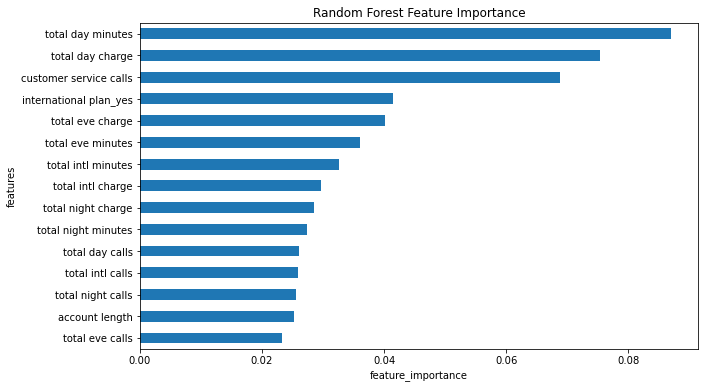

In [23]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
feature_importance.head(15).plot(kind='barh')
plt.xlabel('feature_importance')
plt.ylabel('features')
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis()
plt.show()

In [28]:
#XG BOOST
from xgboost import XGBRegressor
xgb_regressor = XGBRegressor(n_estimators=100, learning_rate=0.1)
xgb_regressor.fit(X_train_scaled, y_train)
from xgboost import XGBClassifier
xgb = XGBClassifier(n_estimators=100,learning_rate=0.1)
xgb.fit(X_train_scaled, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [26]:
!pip install xgboost

In [29]:
#prediction and evaluation
y_pred_xgb = xgb.predict(X_test_scaled)
accuracy = accuracy_score(y_test,y_pred_xgb)
accuracy

0.9565217391304348

In [30]:
#stacking: combine diff types of models
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

#estimators-models

estimators = [
    ('svc',SVC(probability=True)),
    ('dt',DecisionTreeClassifier())
]
stacked = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)
stacked.fit(X_train_scaled, y_train)


StackingClassifier(estimators=[('svc', SVC(probability=True)),
                               ('dt', DecisionTreeClassifier())],
                   final_estimator=LogisticRegression())

In [31]:
#prediction
stacked_pred = stacked.predict(X_test_scaled)
accuracy_s = accuracy_score(y_test,stacked_pred)
accuracy_s

0.9475262368815592